# Activation Functions Note: 1    
#### Abir Hossain | May, 2026

- This notebook has notes on all the different activation functions and details about them.
- The functions:
  + Sigmoid
  + Tanh
  + ReLU
  + Leaky ReLU
  + PReLU
  + ELU
  + SELU
  + GELU
  + Swish
  +  Softplus
  + Softmax
  + Log-Softmax
  + Mish
  + Maxout

# Sigmoid 
- Transforms any real valued number to a value between 0 and 1.
- **Equation:**   $\sigma (x)$ = $\frac{1}{1+e^-x}$
- **Range:**
| x | $\sigma(x)$ |
|---|---|
| $-\infty$ | 0 |
| $\infty$ | 1 |  
- **Continuous** and **Differentiable.**
- **Monotonic:** The function is strictly increasing; as the input increases.
- **Non-Linear.**
- **Derivative:**
  $\frac{d\sigma}{dx}$ = $\frac{d (1+e^{-x})^{-1}}{dx}$  
  $\implies \sigma\prime(x)$ = $(-1)(1+e^{-x})^{-2}(-e^{-x})$  
  $\implies \sigma\prime(x)$ = $\frac {e^{-x}}{(1+e^{-x})^2}$ = $\frac {1+e^{-x}-1}{(1+e^{-x})^2}$  
  $\implies \sigma\prime(x)$ = $\frac {1}{1+e^{-x}} (1-\frac{1}{1+e^{-x}}$)  
  $\implies \sigma\prime(x)$ = $\sigma(x) . (1-\sigma(x))$
- **Pros:**
  + **Probabilistic Interpretation**: Because it squashes output values between 0 and 1.
  + Smooth gradients.
  + It pushes outputs towards the extremes (very close to 0 or 1) while keeping the transition in the middle. This is highly desirable for making clear binary decisions.
- **Cons:**
  + **The Vanishing Gradient Problem (Major Drawback)**: When the input `x` is very large or very small (the "tails" of the S-curve), the gradient (derivative) approaches exactly zero. In deep networks, the gradients shrink exponentially, meaning the early layers stop learning entirely.
  + Because the outputs are never negative or zero, the gradients of the weights during training will all have the same sign. This forces the optimization process to take a "zig-zag" path, making convergence much slower than if the function were zero-centered (like the Tanh function).
  + Computationally Expensive: The formula requires calculating an exponential ($e^{−x}$).
- Use for **Binary Classification-Output Layer.**
- Don't use for Multiclass classification, Hidden Layers. 

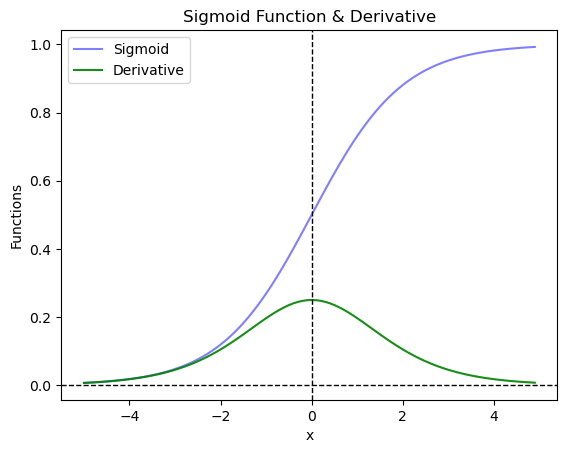

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def Sigmoid(x):
    s = 1/(1 + np.exp(-x))
    ds = s*(1-s)
    return s, ds

x = np.arange(-5.0, 5.0, 0.1)
y1, y2 = Sigmoid(x)

plt.plot(x, y1, label="Sigmoid", alpha=0.5, color= "blue")
plt.plot(x, y2, label="Derivative", alpha=0.9, color="green")
plt.title("Sigmoid Function & Derivative")
plt.xlabel("x")
plt.ylabel("Functions")
plt.axhline(0, color='black', linewidth=1, linestyle="--")  # X-axis
plt.axvline(0, color='black', linewidth=1, linestyle="--")  # Y-axis
plt.legend()
plt.grid(False)

plt.show()

# Tanh(Hyperbolic Tangent)
- Can be thought of as a rescaled and shifted version of `Sigmoid` - that transforms the output values range to (-1, 1).
- **Equation:** $\tanh(x) = \frac{e^x-e^{−x}}{e^x+e^{−x}}$
- - **Range:**
| x | $\sigma(x)$ |
|---|---|
| $-\infty$ | -1 |
| $\infty$ | 1 |  
- **Continuous** and **Differentiable.**
- **Zero-Centered:** Unlike sigmoid, tanh outputs are symmetric around zero. Positive inputs yield positive outputs; negative inputs yield negative outputs.
- **Steeper Gradient:** The slope near zero is 1 (compared to 0.25 for sigmoid), meaning gradients are stronger in the active region.
- **Non-Linear.**
- Historically preferred over sigmoid for hidden layers. Still useful in RNNs/LSTMs and specific architectures where bounded, zero-centered activations are desired.
- **Derivative:**
  $d(\frac{e^x-e^{-x}}{e^x+e^{-x}})$ = $\frac{(e^x+e^{-x}).d(e^x-e^{-x}) - (e^x-e^{-x}).d(e^x+e^{-x})}{(e^x+e^{-x})^2}$  
  $\implies \tanh\prime(x)$ = $\frac {(e^x+e^{-x})^2-(e^x-e^{-x})^2}{(e^x+e^{-x})^2}$  
  $\implies \tanh\prime(x)$ = $\frac {(e^x+e^{-x})^2}{(e^x+e^{-x})^2} - \frac {(e^x-e^{-x})^2}{(e^x+e^{-x})^2}$ = $1 - \tanh^2(x)$  
- **Pros:**
  + **Zero-Centered Outputs:** Weight updates during backpropagation can move in any direction efficiently. This eliminates the zig-zag optimization problem of sigmoid, leading to faster convergence.
  + **Stronger Gradients Near Zero:** The steeper slope means neurons are more sensitive to changes in input around the origin, providing richer learning signals in the early stages of training.
- **Cons:**
  + **Vanishing Gradient Problem:** Like sigmoid, the gradient approaches zero at both tails (x $\rightarrow ± \infty$). Deep networks still suffer from dying gradients in saturated regions.
  + **Computationally Expensive:** Requires two exponential calculations, making it slower than ReLU-based alternatives.
  + **Not Ideal for Output Layers:** The -1 to 1 range doesn't map naturally to probabilities .

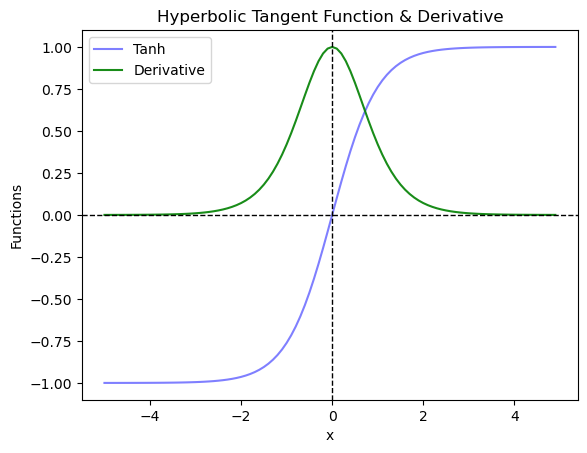

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def Tanh(x):
    T = (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))
    dT = 1 - T**2 
    return T, dT

x = np.arange(-5.0, 5.0, 0.1)
y1, y2 = Tanh(x)

plt.plot(x, y1, label="Tanh", alpha=0.5, color= "blue")
plt.plot(x, y2, label="Derivative", alpha=0.9, color="green")
plt.title("Hyperbolic Tangent Function & Derivative")
plt.xlabel("x")
plt.ylabel("Functions")
plt.axhline(0, color='black', linewidth=1, linestyle="--")  # X-axis
plt.axvline(0, color='black', linewidth=1, linestyle="--")  # Y-axis
plt.legend()
plt.grid(False)

plt.show()

# ReLU(Rectified Linear Unit)
-  It introduces non-linearity through a simple thresholding operation rather than a smooth curve.
-  **Equation:**  $$f(x) = \begin{cases} 
                    x & \text{if } x > 0 \\ 
                    0 & \text{if } x \le 0 
                    \end{cases}$$
- **Range:** [0,$\infty$).
- **Piecewise Linear:** Linear for x$>$0 , constant zero for x$<$0.
- Not differentiable at x=0 (but subdifferentiable; in practice, the derivative at 0 is defined as 0 or 1).
- **Sparse Activation:** For any given input, roughly half the neurons output exactly zero, creating sparsity.
- **Non-Saturating:** Gradient is exactly 1 for all x$>$0, so gradients never vanish in the active region.
- The default choice for hidden layers in almost all modern architectures (`CNNs`, `MLPs`, `Transformers`), paired with `Batch Normalization or similar stabilization techniques`.
- **Pros:**
  + **Computational Efficiency:** Only requires a comparison and max operation, no exponentials, no divisions. Dramatically faster to compute and backpropagate.
  + **Mitigates Vanishing Gradients:** Constant gradient of 1 on the positive side allows error signals to flow backward through many layers without shrinking.
  + **Sparse Representations:** Dead neurons (outputting 0) create efficient, sparse feature representations that can improve generalization.
- **Cons:**
  + **Dying ReLU Problem:** If a neuron's weights push its pre-activation into the negative region permanently, the gradient becomes exactly 0 and the neuron never recovers. It is effectively dead for the rest of training.
  + **Not Zero-Centered:** Outputs are always ≥ 0, reintroducing the zig-zag optimization issue (though less severe than sigmoid due to sparsity and unbounded positive range).
  + **Unbounded Positive Output:** Activations can grow arbitrarily large, potentially causing numerical instability or exploding activations without proper normalization (BatchNorm/LayerNorm).
- **Derivative:** $$f(x) = \begin{cases} 
                    1 & \text{if } x > 0 \\ 
                    0 & \text{if } x < 0 \\
                    \text{Set to 0/0.5 in PyTorch, TensorFlow, NumPy} & \text{at} x = 0
                    \end{cases}$$

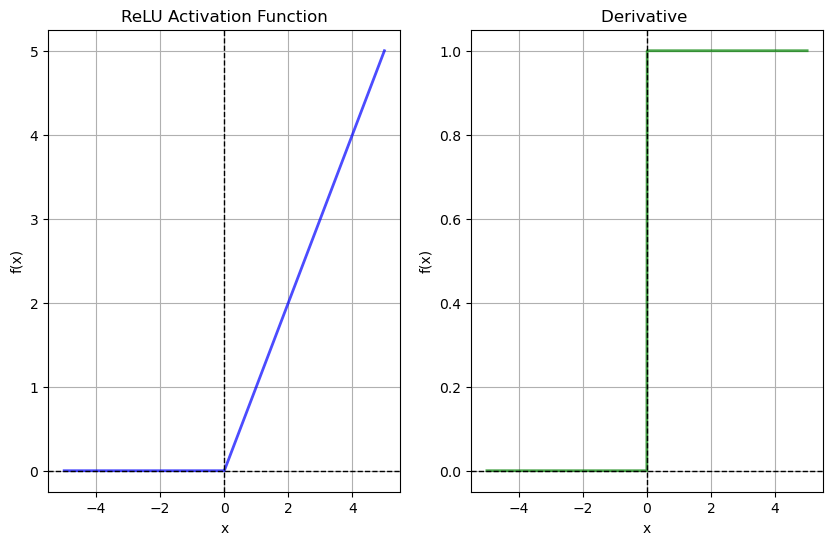

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    # np.maximum(array1, array2) performs elementwise maximum comparison between the arrays. Outputs new array containing the larger value at each position. 
    # vectorized if-else statement for arrays. outputs 1 if true, else 0. 
    return np.maximum(0, x), np.where(x > 0, 1, 0)  

x = np.linspace(-5, 5, 1000)  # np.linspace(start, stop, number of values i want)
y1, y2 = relu(x)

fig, (relu, deriv) = plt.subplots(1, 2, figsize=(10, 6))

relu.plot(x, y1, label='ReLU', color='blue', linewidth=2, alpha=0.7)
relu.set_xlabel('x')
relu.set_ylabel('f(x)')
relu.set_title("ReLU Activation Function")
relu.grid(True)
relu.axhline(0, color='black', linewidth=1, linestyle = "--")
relu.axvline(0, color='black', linewidth=1, linestyle = "--")

deriv.plot(x, y2, label='Derivative', color='green', linewidth=2, alpha=0.7)
deriv.set_xlabel('x')
deriv.set_ylabel('f(x)')
deriv.set_title('Derivative ')
deriv.grid(True)
deriv.axhline(0, color='black', linewidth=1, linestyle = "--")
deriv.axvline(0, color='black', linewidth=1, linestyle = "--")

plt.show()

# Leaky ReLU
Prevents dying neurons by allowing a small, non-zero gradient when x<0x < 0x<0.
**Equation:**  $$f(x) = \begin{cases} 
                    x & \text{if } x > 0 \\ 
                    \alpha x & \text{if } x \le 0 
                    & \text{  |   }\alpha \approx 0.01
                    \end{cases}$$

- **Pros:** Eliminates the dying ReLU problem entirely; retains computational efficiency.
- **Cons:** The leak slope $\alpha$ is a fixed hyperparameter; negative outputs are not learned, just passed through linearly.
- **Use When:** Significant dead neurons with standard ReLU is observed.

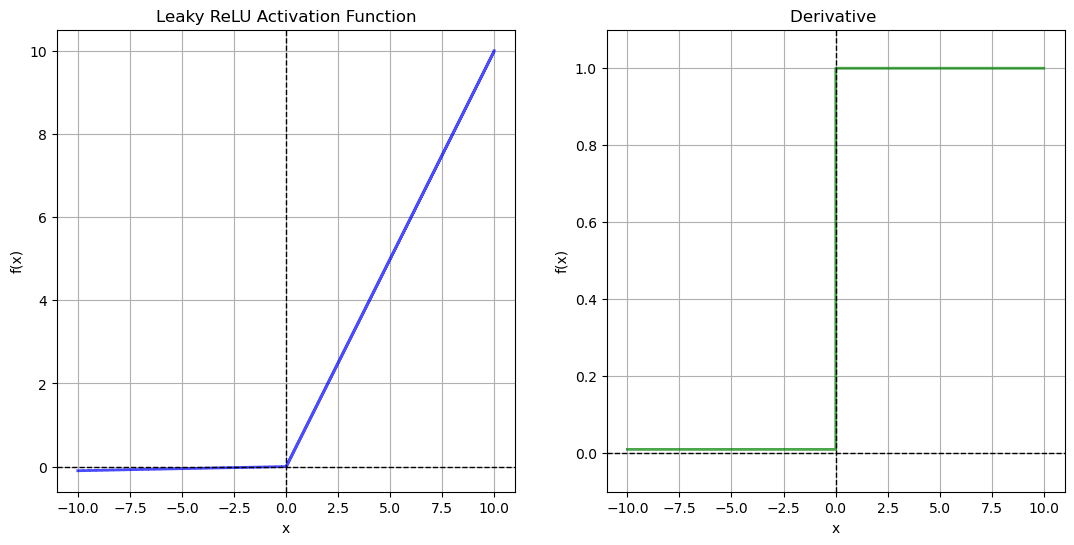

In [31]:
import numpy as np
import matplotlib.pyplot as plt
    
ALPHA=0.01

def LeakyRelu(x):
    return np.where(x>0, x, ALPHA*x)
def Deriv(x):
    return np.where(x>0, 1, ALPHA)

x = np.linspace(-10, 10, 1000)  
y1 = LeakyRelu(x)
y2 = Deriv(x)

fig, (prelu, deriv) = plt.subplots(1, 2, figsize=(13, 6))

prelu.plot(x, y1, label='Leaky ReLU', color='blue', linewidth=2, alpha=0.7, drawstyle='steps-post')
prelu.set_xlabel('x')
prelu.set_ylabel('f(x)')
prelu.set_title("Leaky ReLU Activation Function")
prelu.grid(True)
prelu.axhline(0, color='black', linewidth=1, linestyle = "--")
prelu.axvline(0, color='black', linewidth=1, linestyle = "--")

deriv.plot(x, y2, label='Derivative', color='green', linewidth=2, alpha=0.7, drawstyle='steps-post')
deriv.set_xlabel('x')
deriv.set_ylabel('f(x)')
deriv.set_title('Derivative ')
deriv.grid(True)
deriv.axhline(0, color='black', linewidth=1, linestyle = "--")
deriv.axvline(0, color='black', linewidth=1, linestyle = "--")
deriv.set_ylim(-0.1, 1.1)

plt.show()

# PReLU(Parametric ReLU) 
Same as Leaky ReLU, but $\alpha$ is a learnable parameter optimized during training.

- **Pros:** The network learns the optimal negative slope per channel/neuron, adapting to data distribution.
- **Cons:** Adds extra parameters (risk of overfitting on small datasets); slightly more complex optimization landscape.
- **Use When:** Data is sufficient and goal is for the model to self-tune activation behavior (popularized in ResNet variants).

# ELU(Exponential Linear Unit)
Uses an exponential curve for negative inputs to push mean activation closer to zero.
- **Equation:** $$f(x) = \begin{cases} 
                    x & \text{if } x > 0 \\ 
                    \alpha (e^x-1) & \text{if } x \le 0 
                    \end{cases}$$  
- **Derivative:** $$f\prime(x) = \begin{cases} 
                    1 & \text{if } x > 0 \\ 
                    \alpha \cdot e^x & \text{if } x \le 0 
                    \end{cases}$$ 

- **Pros:** Smooth and differentiable everywhere (including at 0); produces near-zero-centered outputs, accelerating convergence; avoids dying neurons.
- **Cons:** Requires exponential computation for negative inputs, making it slower than ReLU/Leaky ReLU.
- **Use When:** Convergence speed matters more than raw throughput; often in research settings.

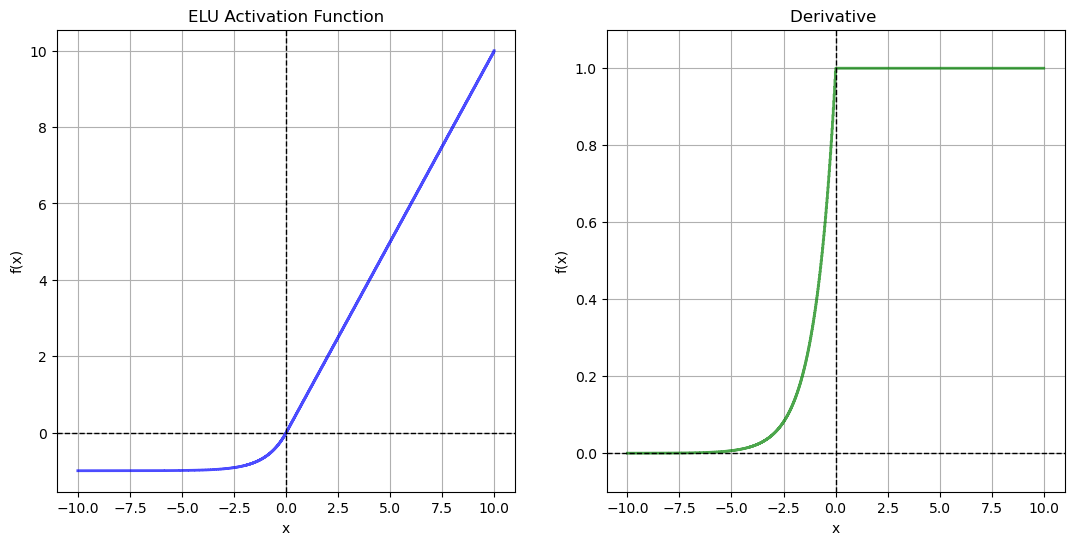

In [41]:
import numpy as np
import matplotlib.pyplot as plt

ALPHA = 1.0  # Standard ELU

def Elu(x):
    return np.where(x>0, x, ALPHA*(np.exp(x) - 1))
def Deriv(x):
    return np.where(x>0, 1, ALPHA*(np.exp(x)))

x = np.linspace(-10, 10, 1000)  
y1 = Elu(x)
y2 = Deriv(x)

fig, (elu, deriv) = plt.subplots(1, 2, figsize=(13, 6))

elu.plot(x, y1, label='ELU', color='blue', linewidth=2, alpha=0.7, drawstyle='steps-post')
elu.set_xlabel('x')
elu.set_ylabel('f(x)')
elu.set_title("ELU Activation Function")
elu.grid(True)
elu.axhline(0, color='black', linewidth=1, linestyle = "--")
elu.axvline(0, color='black', linewidth=1, linestyle = "--")

deriv.plot(x, y2, label='Derivative', color='green', linewidth=2, alpha=0.7, drawstyle='steps-post')
deriv.set_xlabel('x')
deriv.set_ylabel('f(x)')
deriv.set_title('Derivative ')
deriv.grid(True)
deriv.axhline(0, color='black', linewidth=1, linestyle = "--")
deriv.axvline(0, color='black', linewidth=1, linestyle = "--")
deriv.set_ylim(-0.1, 1.1)

plt.show()

# SELU (Scaled Exponential Linear Unit)
SELU is a specialized activation function designed to enable Self-Normalizing Neural Networks (SNNs). Unlike other activations that require external normalization techniques (like Batch Normalization) to keep data stable, SELU automatically pushes neuron activations toward a mean of 0 and a variance of 1 during training, provided specific architectural constraints are met.

- **Equation:** $$f(x) = \lambda \cdot \begin{cases} 
                    x & \text{if } x > 0 \\ 
                    \alpha (e^x-1) & \text{if } x \le 0 
                    \end{cases}$$ 

- **Fixed Constants:** The parameters $\lambda$ and $\alpha$ are not hyperparameters; they are fixed mathematical constants derived to ensure self-normalization:
  + $\lambda \approx 1.0507$
  + $\alpha \approx 1.6732$
- **Self-Normalizing:** This is it's defining feature. If the input has a mean of 0 and variance of 1, the output will also have a mean of 0 and variance of 1. It actively corrects deviations from this distribution.
- **Zero-Centered:** Like Tanh and ELU, it produces negative outputs, helping to center the data.
- **Smooth and Differentiable:** Continuous everywhere, including at $x = 0$.
- **Non-Monotonic for Negative Inputs:** For very negative inputs, the function curves back up slightly due to the exponential term, which helps in stabilizing gradients.
- **Pros:**
  + **Robustness to Vanishing/Exploding Gradients:** By maintaining stable mean and variance across deep layers, it effectively mitigates both vanishing and exploding gradient problems without needing Batch Normalization.
  + **Faster Convergence in Deep Networks:** In very deep `Feedforward Neural Networks (MLPs)`, often converges faster and achieves higher accuracy than ReLU-based networks because the signal remains stable layer-to-layer.
  + **Implicit Regularization:** The self-normalizing property acts as a regularizer, often reducing the need for `Dropout`.
  + **No Hyperparameter Tuning for Activation:** Unlike Leaky ReLU or PReLU, there are no slopes or leaks to tune. The constants are fixed.
- **Cons:**
  + **Strict Architectural Constraints:** It only works reliably in dense, feedforward architectures. It generally fails or provides no benefit in: `CNNs, RNNs, ResNets`.
  + **Sensitive to Initialization:** If `LeCun Normal initialization` is not used, SELU can perform worse than ReLU. 
  + **Computational Cost:** Requires exponential calculations for negative inputs, making it slower than ReLU and comparable to ELU/Tanh.
  + **Incompatible with Standard Dropout:** Standard Dropout changes the variance of the activations, breaking the self-normalizing property. Specifically `Alpha Dropout` preferred.

# Softplus
Softplus is a smooth approximation of the ReLU function. It was popular in early deep learning research before ReLU became dominant.
- **Equation:** $\text{Softplus}(x) = \ln(1 + e^x)$ 
- **Range:** $(0, \infty)$. Strictly positive.
- **Smooth Approximation of ReLU:**
  + For large positive x, $\text{Softplus}(x) \approx x$.
  + For large negative x, $\text{Softplus}(x) \approx 0$.
  + At $x=0$, output is $\ln(2) \approx 0.69$.
- **Derivative:** The derivative of Softplus is exactly the Sigmoid function:
  + $\text{Softplus}^\prime (x) = \sigma(x) = \frac{1}{1+e^{-x}}$.
- Rarely used as a general hidden layer activation today, ReLU is preferred. However, it is commonly used in probabilistic deep learning to ensure parameters like variance or scale remain positive (*Variational Autoencoders*).
- **Pros:**
  + **Differentiable Everywhere:** Unlike ReLU, it has no "dead" corner at zero. Gradients are always non-zero.
  + **Strictly Positive:** Useful in models where outputs must be positive (e.g., predicting variance in probabilistic models).
- **Cons:**
  + **Saturation for Negative Inputs:** For $x < −5$, the gradient (sigmoid) becomes extremely small, leading to vanishing gradients.
  + **Computational Cost:** Logarithm and exponential terms make it much slower than ReLU.
  + **Not Zero-Centered:** Outputs are always positive. 

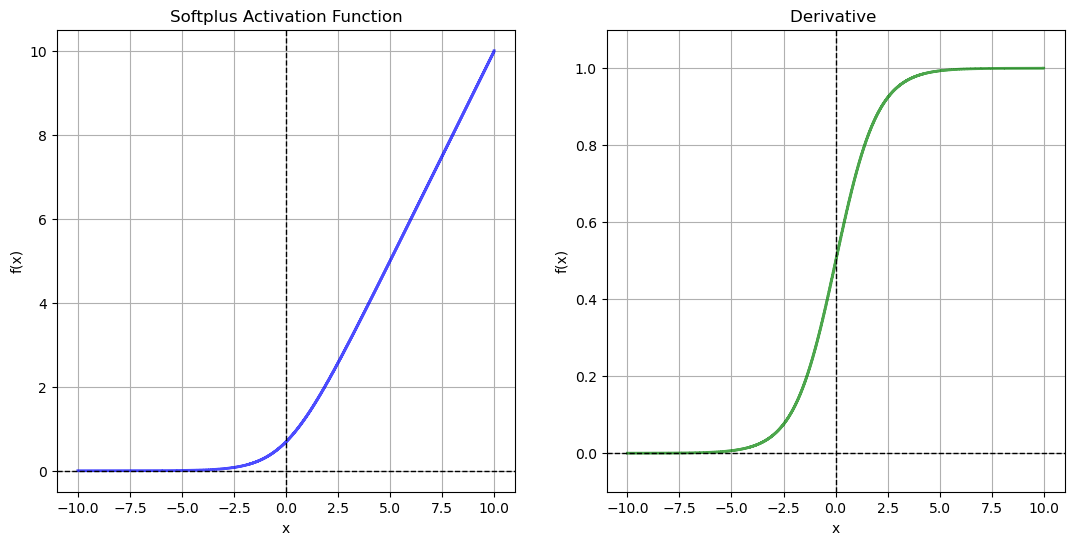

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def Softplus(x):
    return np.log(1 + np.exp(x)), 1/(1+np.exp(-x))

x = np.linspace(-10, 10, 1000)  
y1, y2 = Softplus(x)

fig, (prelu, deriv) = plt.subplots(1, 2, figsize=(13, 6))

prelu.plot(x, y1, label='Softplus', color='blue', linewidth=2, alpha=0.7, drawstyle='steps-post')
prelu.set_xlabel('x')
prelu.set_ylabel('f(x)')
prelu.set_title("Softplus Activation Function")
prelu.grid(True)
prelu.axhline(0, color='black', linewidth=1, linestyle = "--")
prelu.axvline(0, color='black', linewidth=1, linestyle = "--")

deriv.plot(x, y2, label='Derivative', color='green', linewidth=2, alpha=0.7, drawstyle='steps-post')
deriv.set_xlabel('x')
deriv.set_ylabel('f(x)')
deriv.set_title('Derivative ')
deriv.grid(True)
deriv.axhline(0, color='black', linewidth=1, linestyle = "--")
deriv.axvline(0, color='black', linewidth=1, linestyle = "--")
deriv.set_ylim(-0.1, 1.1)

plt.show()

# GELU(Gaussian Error Linear Unit)
GELU is a modern activation function that has become the de facto standard in Transformer-based architectures (such as BERT, GPT, ViT, and most Large Language Models). It can be viewed as a smooth, probabilistic version of ReLU, where the "gate" (whether to pass the input or zero it out) is determined by the input's value relative to a Gaussian distribution.
- **Equation:** The exact mathematical definition involves the Cumulative Distribution Function (CDF) of the standard normal distribution, denoted as $\phi(x)$:
  + $\text{GELU}(x) = x \cdot \phi(x)$
  + Since computing the error function (erf) for $\phi(x)$ is computationally expensive, a highly accurate polynomial approximation is used in practice:
    * $GELU(x) = x\times CDF(x) = x\times \frac{1}{2}\left(1 +erf \left(\frac{x}{\sqrt{2}}\right)\right)$
  + Gaussian error function approximated using the $\tanh$ function:
    * $\text{GELU}(x) \approx 0.5x \left( 1 + \tanh \left[ \sqrt{\frac{2}{\pi}} (x + 0.044715 x^3) \right]\right)$
    * $0.5x$ introduces a linear component to the function.
    * $\tanh$ applies the hyperbolic tangent function to the input, which helps maintain a smooth transition.
    * The scaling factor $\sqrt{\frac{2}{\pi}}$ applies normalization, ensuring the output is within a reasonable range.
  + Sigmoid-based approximation:
    * $GELU_{\text{sigmoid}}(x) = x \times \sigma(1.702\times x)$ 
- **Derivative( for Tanh):**
  + Recall the **tanh** approximation for GELU:  
$\text{GELU}(x) \approx 0.5x \left( 1 + \tanh(\beta) \right)$  
Where, $\beta$ is a helper term: $\beta = \sqrt{\frac{2}{\pi}} (x + 0.044715 x^3)$  
Let, K = $\sqrt{\frac{2}{\pi}} \approx 0.79788$  
Then, $\beta = K . (x + 0.044715 x^3)$  
  + The Derivative Calculation:
Let, $U = 0.5 . x$ and $V = 1 + \tanh(\beta)$  
Then, $\text{GELU}(x) = U \cdot V$  
So, $\frac{d}{dx}\text{GELU}(x) = U^\prime V + UV^\prime$   
$U^\prime= 0.5$  
$V^\prime = \frac{d}{dx}(1 + \tanh(\beta)) = \text{sech}^2(\beta) \cdot \frac{d\beta}{dx}$  
And, $\frac{d\beta}{dx} = K . (1 + 3 \cdot 0.044715 x^2) = K(1 + 0.134145 x^2)$   
  + Combining everything:
$\text{GELU}'(x) = 0.5 [1 + \tanh(\beta)] + 0.5x [\text{sech}^2(\beta) \cdot K(1 + 0.134145 x^2)]$  
  + Final Simplified Formula:  
In code implementations, it is often cleaner to express $\text{sech}^2(\beta) \text{as} (1 - \tanh^2(\beta))$.  
Let, $T = \tanh(\beta)$  
Then, $GELU^\prime(x) = 0.5(1 + T) + 0.5x \cdot (1 - T^2) \cdot K \cdot (1 + 0.134145 x^2)$
 
- **Smooth and Differentiable:** Unlike ReLU, which has a sharp corner at $x = 0$, GELU is smooth everywhere. This allows for stable gradient flow even near zero.
- **Non-Monotonic:** For small negative values, the function dips slightly below zero before approaching zero asymptotically. This non-monotonicity helps the model learn more complex representations.
- **Probabilistic Gating:** The term $\phi(x)$ acts as a soft gate. If x is large and positive, $\phi(x) \approx 1$ (identity function). If x is large and negative, $\phi(x) \approx 0$ (zeroing out). Around zero, it smoothly transitions, weighting the input by its probability of being positive.
- **Unbounded Above, Bounded Below:** Like ReLU, outputs can grow infinitely large for positive inputs, but negative outputs are bounded (approaching 0 from below).
- **Zero-Centered Expectation:** While not strictly zero-centered like Tanh, the smooth transition and negative dip help keep the mean of activations closer to zero than ReLU, aiding optimization.
- **Pros:**
  + **Superior Performance in Transformers:** Empirically, GELU consistently outperforms ReLU and ELU in attention-based models. It handles the complex, high-dimensional interactions in self-attention mechanisms better.
  + **Smooth Gradient Flow:** The absence of hard zeros (unlike ReLU) means gradients never completely vanish due to the activation function itself, reducing the risk of "dead" neurons while avoiding the vanishing gradient issues of sigmoid or tanh.
  + **Implicit Regularization:** The stochastic nature of the gating mechanism (interpreting $\phi(x)$ as a probability) introduces a mild regularizing effect, often improving generalization without needing heavy dropout.
  + **Robustness:** Less sensitive to initialization schemes compared to SELU or Tanh. Works well with standard He or Xavier initialization.
- **Cons:**
  + **Computational Cost:** The approximation requires tanh and cubic operations ($x^3$), making it significantly slower to compute than ReLU. However, on modern GPUs/TPUs, this overhead is often negligible compared to the cost of matrix multiplications in large models.
  + **Complexity:** The formula is less intuitive than ReLU’s simple max(0,x). Debugging or analyzing activation patterns is slightly harder due to the non-linear, non-monotonic shape.
  + **Not Ideal for Simple CNNs:** While it can work in Convolutional Neural Networks, the performance gain over ReLU is often marginal in vision tasks, whereas the computational cost remains. ReLU (or Swish) is often preferred in pure CNNs for efficiency.

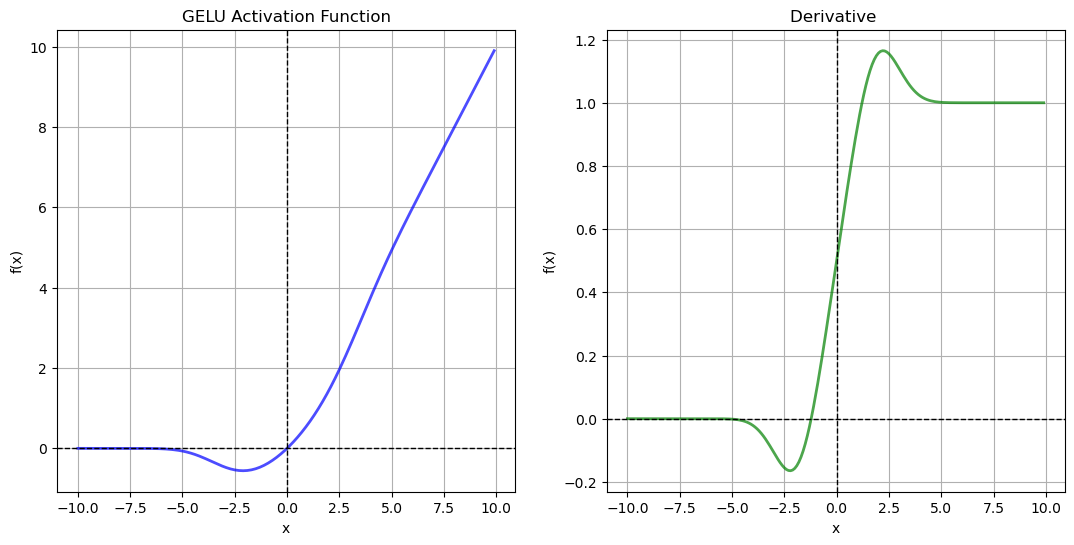

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def Tanh(x):
    T = (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))
    return T

# K = sqrt(2)/pi    
# B = K * (x + 0.044715 * x**3)
# GELU(x) = 0.5 * x (1 + tanh(K * B))
# DERIV(x) = 0.5 * (1+tanh(B)) + 0.5 * x * sech**2(B) * K * (1 + 0.134145 * x**2) 

x = np.arange(-10.0, 10.0, 0.1)
K = np.sqrt(2)/np.pi
BETA = K * (x + 0.044715*(x**3))

GELU = 0.5 * x * (1 + Tanh(K * BETA))
DERIV = 0.5 * (1 + Tanh(BETA)) + 0.5* x * (1 - Tanh(BETA) * Tanh(BETA)) * K * (1 + 0.134145 * (x*x))

fig, (gelu, deriv) = plt.subplots(1, 2, figsize=(13, 6))

gelu.plot(x, GELU, label='GELU', color='blue', linewidth=2, alpha=0.7)
gelu.set_xlabel('x')
gelu.set_ylabel('f(x)')
gelu.set_title("GELU Activation Function")
gelu.grid(True)
gelu.axhline(0, color='black', linewidth=1, linestyle = "--")
gelu.axvline(0, color='black', linewidth=1, linestyle = "--")

deriv.plot(x, DERIV, label='Derivative', color='green', linewidth=2, alpha=0.7)
deriv.set_xlabel('x')
deriv.set_ylabel('f(x)')
deriv.set_title('Derivative ')
deriv.grid(True)
deriv.axhline(0, color='black', linewidth=1, linestyle = "--")
deriv.axvline(0, color='black', linewidth=1, linestyle = "--")

plt.show()

# Swish or SiLU (Sigmoid-weighted Linear Unit)
It was discovered via automated search and has become a strong competitor to ReLU, particularly in efficient mobile networks and some Transformer variants.
- **Equation:**  Swish(x) = $x ⋅ \sigma(x) = \frac{x}{1 + e^{−x}}$
- **Derivative:**$$
  \begin{aligned}
  \text {Swish}^\prime (x) &= x \cdot \sigma^\prime (x) + \sigma (x) \cdot 1\\
                           &= x \cdot \sigma (x) \cdot (1 - \sigma (x)) + \sigma (x) \qquad \text{| Here,}  \,  \sigma^\prime (x) = \sigma (x) \cdot (1 - \sigma(x))\\
                           &= \sigma (x) \cdot (x - x\cdot \sigma (x) + 1)\\
                           &= \sigma (x) \cdot (x + 1 - \text{Swish(x)})
  \end{aligned}
  $$     
- ***NOTE:*** A generalized version exists: $x \cdot \sigma(\beta x)$, where $\beta$ is a learnable parameter, but $\beta = 1$ is the standard.
- **Smooth and Non-Monotonic:** Unlike ReLU, Swish is smooth everywhere. It is non-monotonic for negative inputs, which allows it to capture more complex relationships.
- **Unbounded Above, Bounded Below:** Like ReLU, it goes to $+ \infty$ as $x \to \infty$, preventing saturation on the positive side. As $x \to -\infty$, it approaches 0.
- **Self-Gating:** The term $\sigma(x)$ acts as a soft gate. If x is large positive, the gate opens ($\approx 1$); if negative, the gate closes ($\approx 0$).
- **Pros:**
  + **Consistently Outperforms ReLU:** In many deep architectures (especially EfficientNet and MobileNets), Swish yields higher accuracy than ReLU with minimal computational overhead.
  + **Smooth Gradient:** The derivative is continuous everywhere, avoiding the "kink" at zero found in ReLU, which can help optimization stability.
  + **No Vanishing Gradient on Positive Side:** Since it behaves like identity for large positive x, gradients flow freely.
- **Cons:**
  + **Computational Cost:** Requires computing a sigmoid ($e^{-x}$), making it slower than ReLU. However, it is generally faster than GELU or Tanh.
  + **Not Zero-Centered:** Outputs are mostly positive (with a tiny negative dip), so it shares the non-zero-centered drawback of ReLU/Sigmoid.

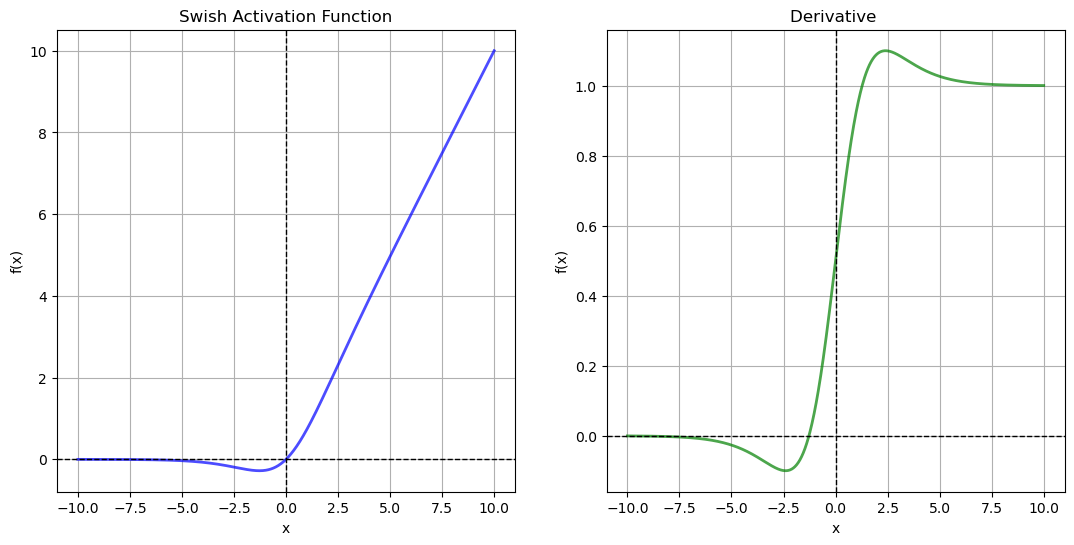

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def Swish(x):
    sigmoid = 1/(1 + np.exp(-x))
    swish = x * sigmoid
    deriv = sigmoid * (x + 1 - swish)
    return swish, deriv

x = np.linspace(-10, 10, 1000)  
swish, deriv = Swish(x)

fig, (s, d) = plt.subplots(1, 2, figsize=(13, 6))

s.plot(x, swish, label='Swish', color='blue', linewidth=2, alpha=0.7)
s.set_xlabel('x')
s.set_ylabel('f(x)')
s.set_title("Swish Activation Function")
s.grid(True)
s.axhline(0, color='black', linewidth=1, linestyle = "--")
s.axvline(0, color='black', linewidth=1, linestyle = "--")

d.plot(x, deriv, label='Derivative', color='green', linewidth=2, alpha=0.7)
d.set_xlabel('x')
d.set_ylabel('f(x)')
d.set_title('Derivative ')
d.grid(True)
d.axhline(0, color='black', linewidth=1, linestyle = "--")
d.axvline(0, color='black', linewidth=1, linestyle = "--")
# deriv.set_ylim(-0.1, 1.1)

plt.show()

# Mish
Mish is a newer activation function that combines the self-gating concept of Swish with the smoothness of Tanh. 
- **Equation:** $\text{     Mish}(x) = x \cdot \tanh(\text{Softplus}(x))$   
Where, $\text{     Softplus}(x) = \ln(1 + e^x)$.
- **Derivative:** $$ \begin{aligned}
      \text{Mish}^\prime(x) &= x \cdot \text{tanh}^\prime\text{(Softplus(x))} +\text{tanh(Softplus(x))}\cdot 1 \\                              &= x \cdot (1 - tanh^2(Softplus(x))) \cdot \frac{1}{1 + e^{-x}} + \tanh(\text{Softplus}(x)) \cdot 1 \\
                            &= (1 - tanh^2(Softplus(x))) \cdot Swish(x) + \tanh(\text{Softplus}(x)) \cdot 1
  \end{aligned} $$
  
- **Smooth and Non-Monotonic:** Like Swish, it is smooth everywhere and non-monotonic for small negative values.
- **Unbounded Above, Bounded Below:** Approaches $+\infty$ for positive x and approaches 0 for negative x.
- **Higher Order Smoothness:** Mish is infinitely differentiable $(C^\infty)$, whereas ReLU is only continuous $(C^0)$ and Swish is once differentiable $(C^1)$. This extreme smoothness can aid optimization in very deep networks.
- Primarily in Computer Vision tasks where accuracy is paramount and inference speed is secondary. It is less common in NLP/Transformers due to the high cost compared to GELU/SiLU.
- **Pros:**
  + **Improved Gradient Flow:** The combination of Tanh and Softplus creates a wider "positive acceptance interval" than ReLU, allowing more information to pass through during backpropagation.
  + **Regularization Effect:** The non-monotonicity and smoothness act as implicit regularizers, often reducing the need for heavy dropout.
  + **State-of-the-Art in Vision:** Has shown superior performance to ReLU, Swish, and ELU in various image classification and object detection benchmarks.
- **Cons:**
  + **Computationally Expensive:** Requires both an exponential (for softplus) and a hyperbolic tangent. It is significantly slower than ReLU and Swish.
  + **Memory Intensive:** The complex computation graph can increase memory usage during training.

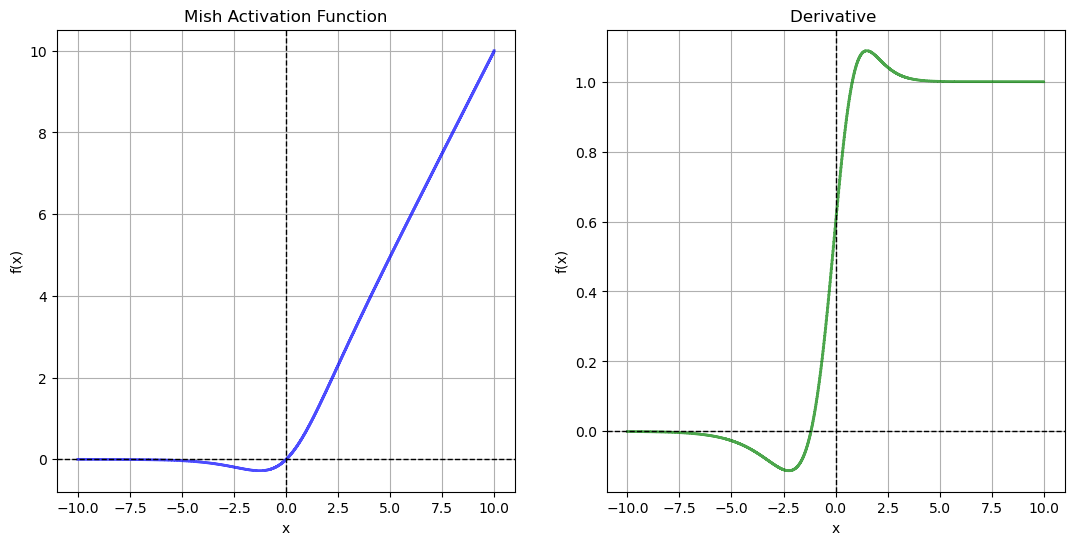

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def Tanh(y):
    return (np.exp(y) - np.exp(-y))/(np.exp(y) + np.exp(-y))
def Mish(x):
    sigmoid = 1/(1 + np.exp(-x))
    softplus = np.log(1 + np.exp(x))
    F1 = Tanh(softplus)
    F2 = x * sigmoid   # Swish
    mish = x * F1
    deriv = (1 - F1**2) * F2 + F1
    return mish, deriv

x = np.linspace(-10, 10, 1000)  
mish, deriv = Mish(x)

fig, (m, d) = plt.subplots(1, 2, figsize=(13, 6))

m.plot(x, swish, label='Mish', color='blue', linewidth=2, alpha=0.7, drawstyle='steps-post')
m.set_xlabel('x')
m.set_ylabel('f(x)')
m.set_title("Mish Activation Function")
m.grid(True)
m.axhline(0, color='black', linewidth=1, linestyle = "--")
m.axvline(0, color='black', linewidth=1, linestyle = "--")

d.plot(x, deriv, label='Derivative', color='green', linewidth=2, alpha=0.7, drawstyle='steps-post')
d.set_xlabel('x')
d.set_ylabel('f(x)')
d.set_title('Derivative ')
d.grid(True)
d.axhline(0, color='black', linewidth=1, linestyle = "--")
d.axvline(0, color='black', linewidth=1, linestyle = "--")
# deriv.set_ylim(-0.1, 1.1)

plt.show()

# Softmax
Softmax is not typically used in hidden layers; it is the standard activation for the output layer of multi-class classification problems. It converts a vector of raw scores (logits) into a probability distribution.
- **Equation:** For a vector z with K classes:  $\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$ 
- **Output Range:** Each output is between 0 and 1.
- **Sum to One:** The sum of all outputs in the vector is exactly 1. This allows interpretation as probabilities.
- **Differentiable:** Smooth and differentiable everywhere.
- **Pros:**
  + **Probabilistic Interpretation:** Perfect for multi-class classification (ImageNet with 1000 classes). The output states the model's confidence for each class.
  + **Amplifies Differences:** The exponential function exaggerates differences between large and small logits, pushing the highest score closer to 1 and others closer to 0.
- **Cons:**
  + **Not for Hidden Layers:** It couples all neurons in the layer together due to the denominator sum. This makes backpropagation complex and prevents independent feature learning in hidden layers.
  + **Sensitive to Outliers:** Large logits can dominate the distribution, causing vanishing gradients for the non-dominant classes.
  + **Computational Cost:** Requires exponentials and a summation across all classes.

# No Plots or Derivatives: 
- Plotting this and making sense of it intuitively from graph, would take an unnecessary amount of effort when the task is simply to see how the function acts while data-passing through **ML-Learning** steps. But in this case derivative requires same number of partial derivatives with respect to the K classes. That makes the whole purpose of building intuition through visualization, defeated.
- However, how activation functions work and their usefulness should be clear if we study the earlier ones. So not doing the derivatives or visualizations for these. 

# Log-Softmax
Log-Softmax is simply the natural logarithm of the Softmax function. It is mathematically equivalent to Softmax but computed in a numerically stable way for loss calculation.
- **Equation:** $\text{LogSoftmax}(z)_i = \ln\left( \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \right) = z_i - \ln\left( \sum_{j=1}^{K} e^{z_j} \right)$
- **Output Range:** $(-\infty, 0]$. Outputs are negative or zero.
- **Numerical Stability:** Directly computing $\ln(\text{Softmax}(z))$ can lead to underflow if Softmax output is near 0 or overflow if $e^{z_i}$ is huge). The Log-Softmax formula uses the "Log-Sum-Exp" trick to stabilize this.
- *Log-Softmax + NLL Loss or just CrossEntropyLoss* ***over*** *Softmax + CrossEntropy* for multi-class classification is always preferred. It is numerically safer and faster.
- **Pros:**
  + **Stable Loss Calculation:** When combined with Negative Log-Likelihood (NLL) loss or Cross-Entropy Loss, using Log-Softmax prevents numerical instability (NaNs) during training.
  + **Efficient Backprop:** Most deep learning frameworks fuse Log-Softmax and NLL Loss into a single optimized operation (CrossEntropyLoss in PyTorch does this internally).
- **Cons:**
  + **Harder to Interpret:** Outputs are log-probabilities, not direct probabilities. You must exponentiate them to get readable probabilities.
  + **Same Coupling Issue as Softmax:** Not suitable for hidden layers.

# No Plots or Derivatives: 

# Maxout
Maxout is a unique activation function that learns the activation shape itself. Instead of applying a fixed function (like ReLU), it outputs the maximum of several linear transformations.
- **Equation:**For an input x and k linear filters:  
  $\text{Maxout}(x) = \max_{i \in [1, k]} (w_i^T x + b_i)$  
  *usually*, k = 2 to 5
- **Piecewise Linear Convex Function:** It approximates any convex function by taking the max of linear segments.
    Learnable Shape: The "activation" is determined by the weights $w_i$ and biases $b_i$, which are learned during training.
- **Non-Saturating:** Like ReLU, it does not saturate for positive inputs.
- Mostly of historical interest or in specific research contexts where model capacity is limited but parameter count is not. Rarely used in modern large-scale deep learning due to inefficiency. 
- **Pros:**
  + **Universal Approximator:** A Maxout network can approximate any continuous function with fewer neurons than ReLU networks.
  + **Mitigates Vanishing Gradients:** Since it picks the max linear unit, at least one path always has a gradient of 1 (for the winning unit).
  + **Robustness:** Less sensitive to initialization than ReLU.
- **Cons:**
  + **Parameter Explosion:** It requires k times more parameters (weights and biases) per neuron than ReLU. This increases memory usage and risk of overfitting.
  + **Computational Cost:** Computing the max over k linear projections is more expensive than a simple max(0,x).
  + **Less Common Today:** With the advent of Batch Normalization and better initialization schemes, the advantages of Maxout have diminished, and ReLU/GELU have become standard due to efficiency.

# No Plots or Derivatives: 